In [172]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as mp 
import seaborn as s
import tensorflow as tf

Load dataset

In [173]:
df=pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

View Dataset

In [174]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [175]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [176]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1490,8016-ZMGMO,Female,1,Yes,No,66,Yes,Yes,DSL,No,...,Yes,No,Yes,No,One year,Yes,Bank transfer (automatic),70.85,4738.85,No
3823,9065-ZCPQX,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Bank transfer (automatic),78.85,5763.15,No
2245,6050-FFXES,Female,0,Yes,No,69,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),105.35,7240.65,No
1244,2223-KAGMX,Female,0,No,No,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.40,289.3,Yes
3421,6719-FGEDO,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),97.00,7104.2,No


In [177]:
df.shape

(7043, 21)

In [178]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data type

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Change DataType

In [180]:
df['TotalCharges']=df['TotalCharges'].str.strip()
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

Statics

In [181]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Null Values

In [182]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Heandle null values

In [183]:
df["TotalCharges"]=df["TotalCharges"].fillna(
    df["TotalCharges"].mean()
)

Duplicate Values

In [184]:
df.duplicated().sum()

np.int64(0)

Outliers

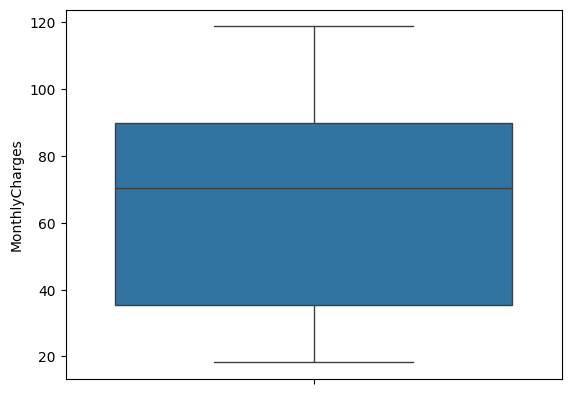

In [185]:
s.boxplot(df['MonthlyCharges'])
mp.show()

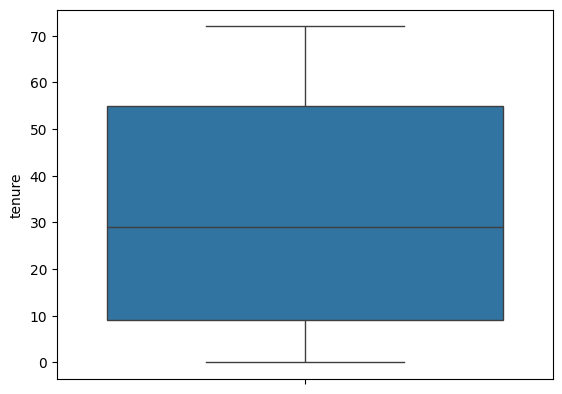

In [186]:
s.boxplot(df['tenure'])
mp.show()

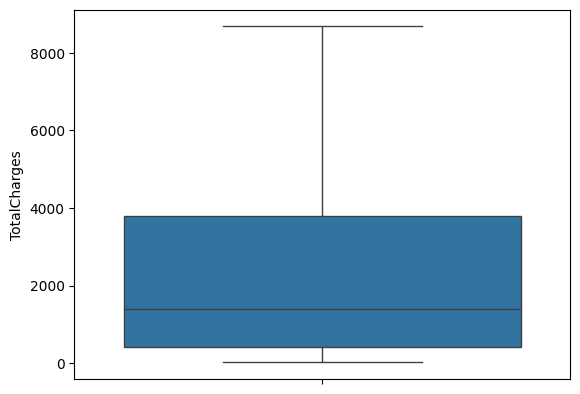

In [187]:
s.boxplot(df['TotalCharges'])
mp.show()

Encoding

In [188]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [189]:
label_columns=[
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]
encoders={}
for col in label_columns:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    encoders[col]=le

In [190]:
joblib.dump(
    encoders,
    "../model/label_encoders.pkl"
)

['../model/label_encoders.pkl']

In [191]:
from sklearn.preprocessing import OneHotEncoder
en=OneHotEncoder()

In [192]:
multi_columns = [
    "InternetService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]
encoders={}
for col in multi_columns:
    ohe = OneHotEncoder()
    result=ohe.fit_transform(df[[col]])
    result=result.toarray()
    new_col=list(ohe.categories_)[0]
    print(col,new_col)
    for i in range(len(new_col)):
        df[new_col[i]+'_'+col]=result[:,i]
    encoders[col] = ohe
    df.drop(columns=[col],inplace=True)

joblib.dump(encoders, "../model/onehot_encoders.pkl")

InternetService ['DSL' 'Fiber optic' 'No']
MultipleLines ['No' 'No phone service' 'Yes']
OnlineSecurity ['No' 'No internet service' 'Yes']
OnlineBackup ['No' 'No internet service' 'Yes']
DeviceProtection ['No' 'No internet service' 'Yes']
TechSupport ['No' 'No internet service' 'Yes']
StreamingTV ['No' 'No internet service' 'Yes']
StreamingMovies ['No' 'No internet service' 'Yes']
Contract ['Month-to-month' 'One year' 'Two year']
PaymentMethod ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check']


['../model/onehot_encoders.pkl']

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   object 
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   PaperlessBilling                         7043 non-null   int64  
 8   MonthlyCharges                           7043 non-null   float64
 9   TotalCharges                             7043 non-null   float64
 10  Churn                                    7043 no

In [194]:
df.sample(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,No_StreamingMovies,No internet service_StreamingMovies,Yes_StreamingMovies,Month-to-month_Contract,One year_Contract,Two year_Contract,Bank transfer (automatic)_PaymentMethod,Credit card (automatic)_PaymentMethod,Electronic check_PaymentMethod,Mailed check_PaymentMethod
4550,4625-XMOYM,0,0,1,1,72,1,1,26.25,1988.05,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4540,6728-WYQBC,1,0,0,0,1,1,0,20.95,20.95,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2376,9314-QDMDW,1,0,0,0,11,1,1,61.25,729.95,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Feature Scalling

In [195]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scale_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[scale_columns] = scaler.fit_transform(df[scale_columns])

joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

corelation

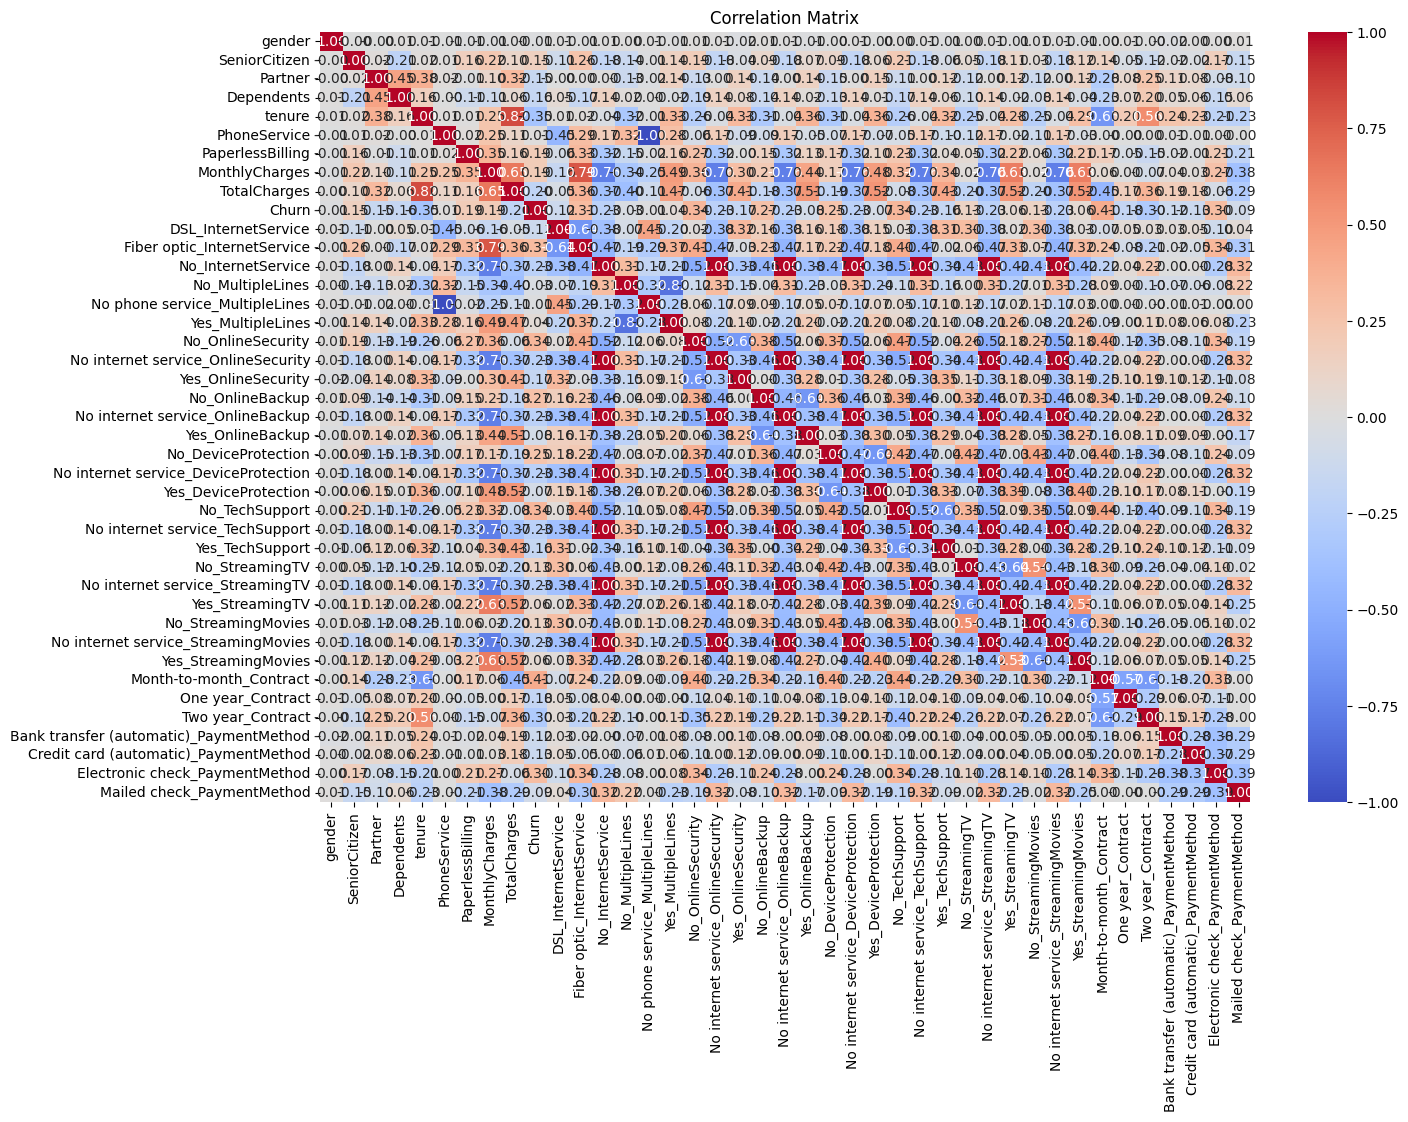

In [196]:
mp.figure(figsize=(15,10))

s.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

mp.title("Correlation Matrix")

mp.show()

Divid input and output features

In [197]:
y=df['Churn']
x=df.drop(columns=['customerID','Churn'])

divid train and test data

In [198]:
x_train,x_test,y_train,y_test=sk.model_selection.train_test_split(x,y,test_size=0.2)

ANN

In [199]:
model=tf.keras.Sequential([
      tf.keras.layers.Dense(64,activation='relu'),
      tf.keras.layers.Dense(32,activation='relu'),
      tf.keras.layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [200]:
es=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
mc=tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [201]:
history=model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es,mc]
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7712 - loss: 0.4699 - val_accuracy: 0.7959 - val_loss: 0.4200
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7937 - loss: 0.4291 - val_accuracy: 0.8075 - val_loss: 0.4130
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8010 - loss: 0.4221 - val_accuracy: 0.8039 - val_loss: 0.4134
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7999 - loss: 0.4193 - val_accuracy: 0.8172 - val_loss: 0.4098
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8054 - loss: 0.4164 - val_accuracy: 0.8021 - val_loss: 0.4128
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8079 - loss: 0.4115 - val_accuracy: 0.8172 - val_loss: 0.4114
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4100 - val_accuracy: 0.8137 - val_loss: 0.4122
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4077 - val_accu

In [202]:
loss,accuracy=model.evaluate(
                x_test,
                y_test
                )

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7970 - loss: 0.4201 


In [203]:
y_pred=model.predict(x_test)

y_pred=(y_pred>0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [204]:
print("loss = ",loss)
print("accuracy = ",accuracy)

loss =  0.4201242923736572
accuracy =  0.7970191836357117


Accuracy Curve

In [205]:
import matplotlib.pyplot as plt

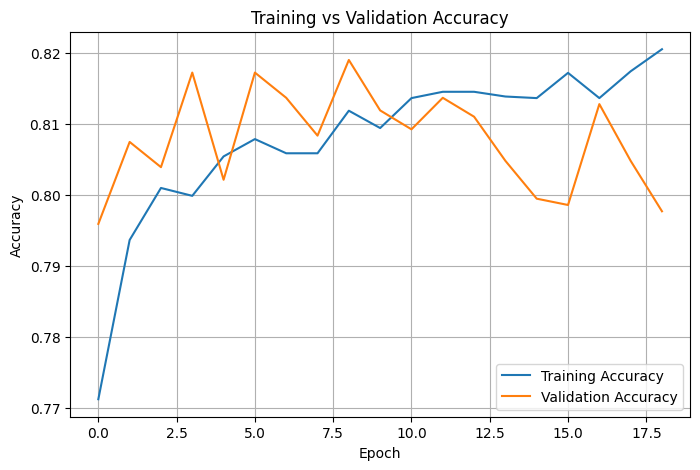

In [206]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid()

plt.savefig("../images/accuracy_curve.png")

plt.show()

Loss Curve

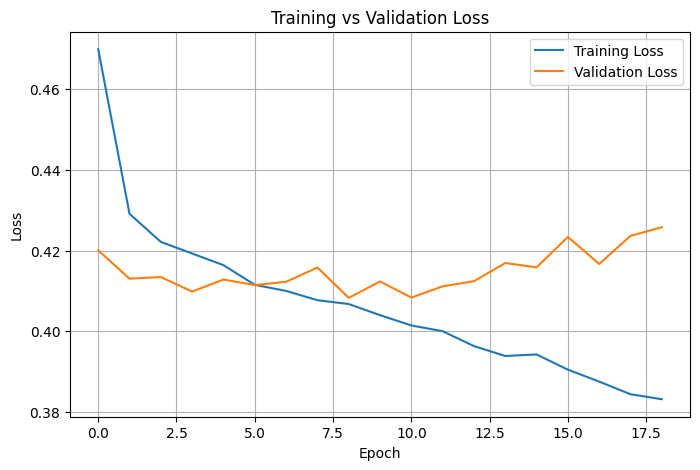

In [207]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.savefig("../images/loss_curve.png")

plt.show()

Classification Report

In [208]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1019
           1       0.67      0.52      0.58       390

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



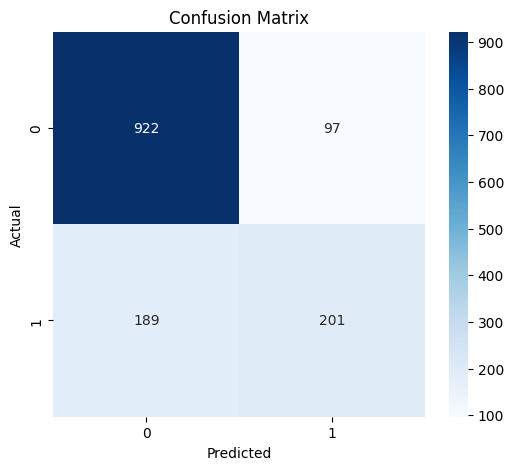

In [209]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

s.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../images/confusion_matrix.png")

plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


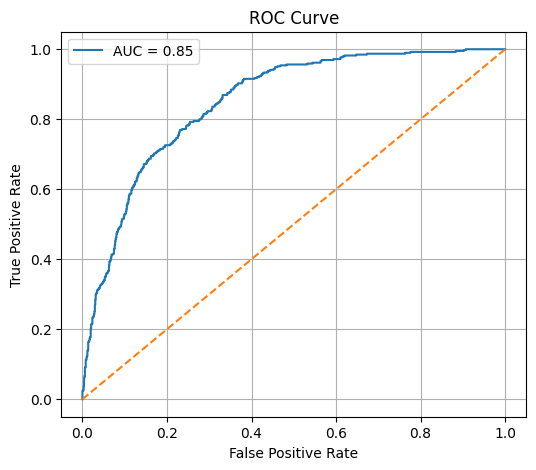

In [210]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_prob = model.predict(x_test)

fpr,tpr,_ = roc_curve(y_test,y_prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.savefig("../images/roc_curve.png")

plt.show()

In [211]:
model.save("../model/churn_model.keras")